In [2]:
import pandas as pd

df=pd.read_csv("dynamic_pricing_dataset.csv")
df.head()

,order_id,date,product_id,category,price,quantity,base_price,discount,demand_factor,revenue
0,1,2023-01-01,P1,Home,358.40,85,448,20,1.34,30464.00
1,2,2023-01-01,P2,Home,198.90,72,221,10,1.28,14320.80
2,3,2023-01-01,P3,Electronics,1460.70,70,1623,10,1.11,102249.00
3,4,2023-01-01,P4,Clothing,515.85,57,543,5,1.10,29403.45
4,5,2023-01-01,P5,Electronics,1599.80,61,1684,5,1.10,97587.80


In [2]:
df.shape


(2700, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       2700 non-null   int64  
 1   date           2700 non-null   object 
 2   product_id     2700 non-null   object 
 3   category       2700 non-null   object 
 4   price          2700 non-null   float64
 5   quantity       2700 non-null   int64  
 6   base_price     2700 non-null   int64  
 7   discount       2700 non-null   int64  
 8   demand_factor  2700 non-null   float64
 9   revenue        2700 non-null   float64
dtypes: float64(3), int64(4), object(3)
memory usage: 211.1+ KB


In [6]:
df.columns

Index(['order_id', 'date', 'product_id', 'category', 'price', 'quantity',
       'base_price', 'discount', 'demand_factor', 'revenue'],
      dtype='object')

In [8]:
df.isnull().sum()

order_id         0
date             0
product_id       0
category         0
price            0
quantity         0
base_price       0
discount         0
demand_factor    0
revenue          0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df['revenue'] = df['price'] * df['quantity']
df['month'] = pd.to_datetime(df['date']).dt.month
df['day'] = pd.to_datetime(df['date']).dt.day_name()

In [11]:
df.columns


Index(['order_id', 'date', 'product_id', 'category', 'price', 'quantity',
       'base_price', 'discount', 'demand_factor', 'revenue', 'month', 'day'],
      dtype='object')

## EDA


#### 1. Category-wise performance

In [3]:
df.groupby('category')[['revenue', 'quantity']].sum()

,revenue,quantity
category,,
Clothing,23079721.05,49873
Electronics,61537646.70,53898
Home,12448652.10,45770


In [4]:
df.groupby('category')[['revenue', 'quantity']].sum().sort_values(by='revenue', ascending=False)

,revenue,quantity
category,,
Electronics,61537646.70,53898
Clothing,23079721.05,49873
Home,12448652.10,45770


#### 👉 Insight:
The Electronics Category Earns more.

### 2. Price vs Quantity

In [5]:
import matplotlib.pyplot as plt 

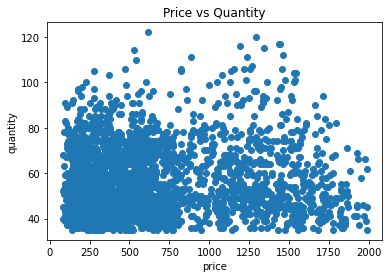

In [9]:
plt.scatter(df['price'], df['quantity'])
plt.xlabel("price")
plt.ylabel("quantity")
plt.title("Price vs Quantity")
plt.show()


“I observed an inverse relationship—higher prices generally reduce demand.”

In [11]:
##Grouping

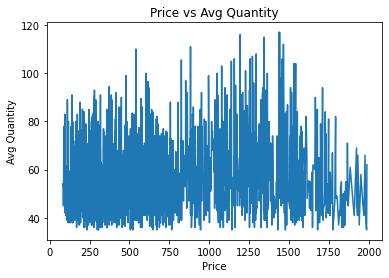

In [10]:
price_analysis = df.groupby('price')['quantity'].mean().reset_index()

plt.plot(price_analysis['price'], price_analysis['quantity'])
plt.xlabel("Price")
plt.ylabel("Avg Quantity")
plt.title("Price vs Avg Quantity")
plt.show()


### Elasticity

In [12]:
import numpy as np

In [13]:
df['log_price'] = np.log(df['price'])
df['log_quantity'] = np.log(df['quantity'])

In [14]:
##Calculate Elasticity

elasticity = df['log_quantity'].corr(df['log_price'])
print("Elasticity:", elasticity)

Elasticity: 0.09514080568144272


###  Average Price & Quantity per Product

In [18]:
product_summary = df.groupby('product_id')[['price', 'quantity', 'revenue']].mean().reset_index()
product_summary.head()

,product_id,price,quantity,revenue
0,P1,593.864167,55.150000,33723.042778
1,P10,669.346667,54.655556,36101.029167
2,P11,664.038889,55.022222,37555.233056
3,P12,609.676111,54.527778,33515.947222
4,P13,643.713056,55.233333,35233.377500


### Top Product visualization

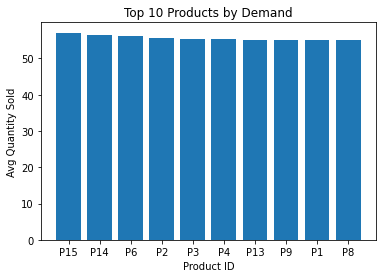

In [22]:
import matplotlib.pyplot as plt

top_products = product_summary.sort_values(by='quantity', ascending=False).head(10)

plt.bar(top_products['product_id'], top_products['quantity'])
plt.xlabel("Product ID")
plt.ylabel("Avg Quantity Sold")
plt.title("Top 10 Products by Demand")
plt.show()

In [23]:
## Top Performing Proucts by comparing average price, quantity, and revenue

### Divide Data into Price Levels

In [24]:
df['price_category'] = pd.cut(df['price'], bins=3, labels=['Low', 'Medium', 'High'])

In [25]:
df.columns

Index(['order_id', 'date', 'product_id', 'category', 'price', 'quantity',
       'base_price', 'discount', 'demand_factor', 'revenue', 'log_price',
       'log_quantity', 'price_category'],
      dtype='object')

In [26]:
price_sensitivity = df.groupby('price_category')['quantity'].mean()
print(price_sensitivity)

price_category
Low       54.248540
Medium    59.058939
High      56.266234
Name: quantity, dtype: float64


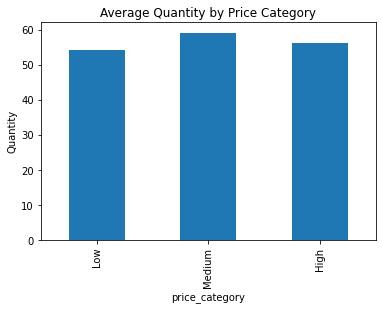

In [27]:
price_sensitivity.plot(kind='bar')
plt.title("Average Quantity by Price Category")
plt.ylabel("Quantity")
plt.show()

### i grouped prices into low, medium, and high categories and observed how demand changes. This helped me identify price-sensitive behavior in a simple way.